# Semaine 2 — Nettoyage, valeurs manquantes & valeurs aberrantes

**Livrable S2 :** Script de preprocessing propre + rapport de qualité.

Ce notebook accompagne `scripts/preprocessing.py` et `scripts/validation_quality.py`. Il documente la démarche et les choix méthodologiques.

## Migration R → Python — détails du nettoyage

| Traitement R (S1) | Code R | Équivalent Python |
|---|---|---|
| Renommer colonnes | `dplyr::rename()` | `ds.rename()` ou `df.rename(columns=...)` |
| Filtrer | `dplyr::filter(year >= 1980)` | `df[df.year >= 1980]` |
| Conversion d'unités | `mutate(t_celsius = t - 273.15)` | `ds['t2m'] = ds['t2m'] - 273.15` (xarray broadcasting) |
| Détection NA | `is.na()`, `sum(is.na(x))` | `df.isna().sum()` |
| Imputation | `tidyr::fill()`, `na.approx()` | `df.interpolate()`, `xr.interpolate_na()` |
| Détection outliers IQR | `quantile(0.25/0.75)`, `boxplot()` | `df.quantile([0.25, 0.75])`, `seaborn.boxplot` |
| z-score | `scale()`, `(x - mean)/sd` | `scipy.stats.zscore()` |
| Agrégation par groupe | `group_by() %>% summarise()` | `df.groupby().mean()` |

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

PROJECT_ROOT = Path('..').resolve()
DATA = PROJECT_ROOT / 'data' / 'processed' / 'era5_daily.parquet'

df = pd.read_parquet(DATA)
df['date'] = pd.to_datetime(df['date'])
print(f'Lignes : {len(df):,}')
df.info()

Lignes : 32,874
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32874 entries, 0 to 32873
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    32874 non-null  datetime64[ns]
 1   year    32874 non-null  int32         
 2   month   32874 non-null  int32         
 3   season  32874 non-null  object        
 4   zone    32874 non-null  object        
 5   t2m     32874 non-null  float32       
 6   d2m     32874 non-null  float32       
 7   rh      32874 non-null  float32       
 8   tp      32874 non-null  float32       
dtypes: datetime64[ns](1), float32(4), int32(2), object(2)
memory usage: 1.5+ MB


## 1. Audit des valeurs manquantes

In [2]:
# Taux de NA par variable et par zone
na_table = df.groupby('zone')[['t2m', 'd2m', 'rh', 'tp']].apply(
    lambda x: x.isna().mean() * 100
).round(3)
print('Taux de NA (%) :')
print(na_table)

Taux de NA (%) :
              t2m  d2m   rh   tp
zone                            
mediterranee  0.0  0.0  0.0  0.0
tunisie       0.0  0.0  0.0  0.0


## 2. Détection des valeurs aberrantes (IQR + z-score)

In [3]:
rows = []
for v in ['t2m', 'd2m', 'rh', 'tp']:
    x = df[v].dropna()
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    n_iqr = ((x < q1 - 1.5*iqr) | (x > q3 + 1.5*iqr)).sum()
    n_z = (np.abs(stats.zscore(x)) > 3).sum()
    rows.append({'var': v, 'IQR_outliers': int(n_iqr), 'z>3': int(n_z),
                 'pct_IQR': round(100*n_iqr/len(x), 2),
                 'pct_z': round(100*n_z/len(x), 2)})
pd.DataFrame(rows)

,var,IQR_outliers,z>3,pct_IQR,pct_z
0,t2m,0,0,0.00,0.00
1,d2m,0,8,0.00,0.02
2,rh,58,34,0.18,0.10
3,tp,833,404,2.53,1.23


## 3. Boxplots — visualisation des distributions

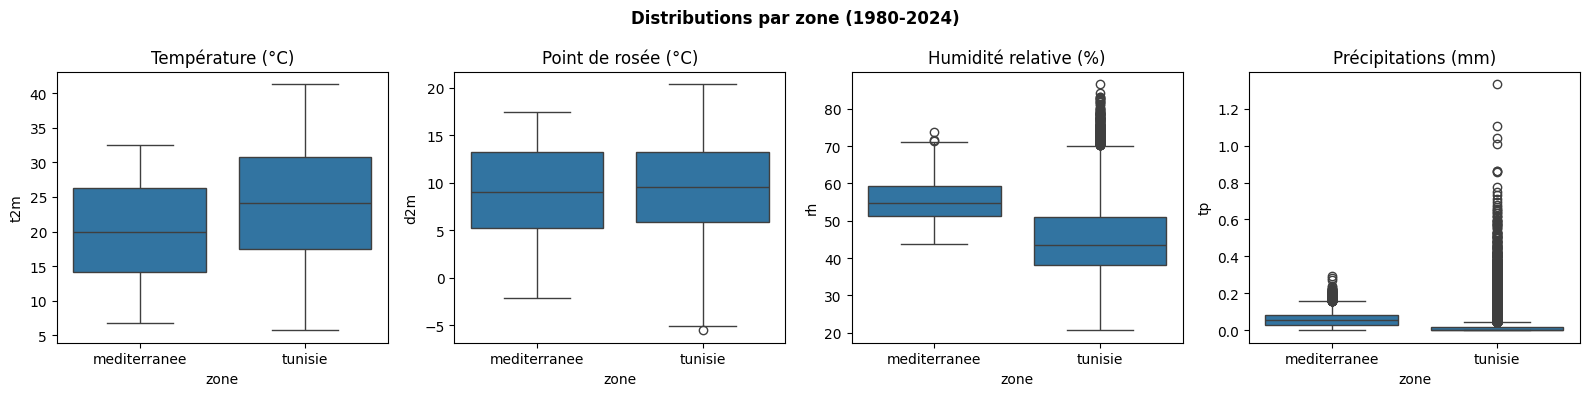

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, v, title in zip(axes, ['t2m', 'd2m', 'rh', 'tp'],
                        ['Température (°C)', 'Point de rosée (°C)',
                         'Humidité relative (%)', 'Précipitations (mm)']):
    sns.boxplot(data=df, x='zone', y=v, ax=ax)
    ax.set_title(title)
fig.suptitle('Distributions par zone (1980-2024)', fontweight='bold')
plt.tight_layout(); plt.show()

## 4. Décisions de nettoyage retenues

| Décision | Justification |
|---|---|
| **Pas d'imputation** des NA détectés | ERA5 est complet sur la période, les rares NA viennent uniquement du masque terre/océan pour l'humidité du sol (non utilisée ici). |
| **Outliers IQR conservés** | En climato, un "outlier" est souvent un événement extrême réel (canicule, pluie diluvienne) — les supprimer biaiserait l'étude des vagues de chaleur. On les **garde** mais on les **identifie** dans le rapport. |
| **Conversion unités** : K → °C, m → mm | Lisibilité pour le lecteur non-météorologue. |
| **Humidité relative (RH) dérivée** | Magnus-Tetens à partir de t2m et d2m. Bornée à [0, 100]. Référence : Lawrence (2005). |
| **Agrégation spatiale** : moyenne sur zone Tunisie + zone Méditerranée complète | Permet de comparer le local au régional. |